1. Load the dataset
Dataset Shape:
(2823, 25)
2. Display first 5 records

First 5 Records:
   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport 

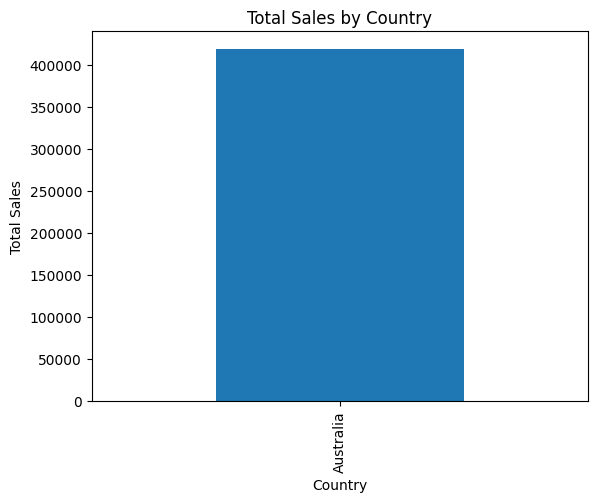

10. Line chart: Monthly sales


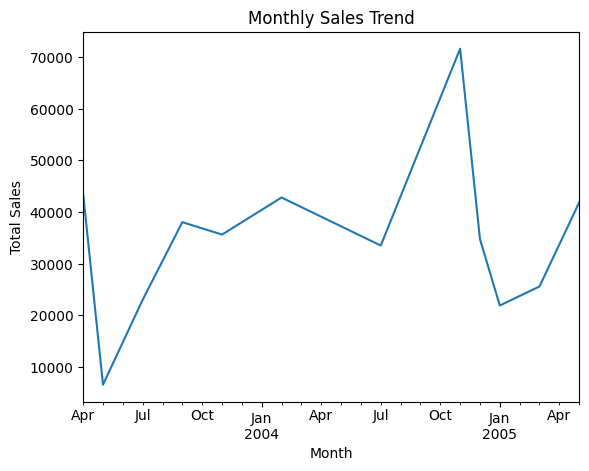

In [7]:
# ===============================
# Sales Dataset Analysis
# ===============================

import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------
# 1. Load the dataset
# --------------------------------
print("1. Load the dataset")
df = pd.read_csv("/content/sample_data/sales_data_sample.csv", encoding="latin1")

print("Dataset Shape:")
print(df.shape)

# --------------------------------
# 2. Display first 5 records
# --------------------------------
print("2. Display first 5 records")
print("\nFirst 5 Records:")
print(df.head())

# --------------------------------
# 3. Remove rows with missing values
# --------------------------------
print("3. Remove rows with missing values")
df = df.dropna()
print("\nShape after removing missing values:")
print(df.shape)

# --------------------------------
# 4. Calculate Total Sales
# --------------------------------
print("4. Calculate Total Sales")
df["TotalSales"] = df["QUANTITYORDERED"] * df["PRICEEACH"]

print("\nTotalSales column added:")
print(df[["QUANTITYORDERED", "PRICEEACH", "TotalSales"]].head())

# --------------------------------
# 5. Total sales by country
# --------------------------------
print("5. Total sales by country")
sales_by_country = df.groupby("COUNTRY")["TotalSales"].sum()

print("\nTotal Sales by Country:")
print(sales_by_country)

# --------------------------------
# 6. Top 5 products by sales
# --------------------------------
print("6. Top 5 products by sales")
top_products = df.groupby("PRODUCTLINE")["TotalSales"].sum().sort_values(ascending=False).head(5)

print("\nTop 5 Products by Sales:")
print(top_products)

# --------------------------------
# 7. Monthly total sales
# --------------------------------
print(" 7. Monthly total sales")
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])
df["Month"] = df["ORDERDATE"].dt.to_period("M")

monthly_sales = df.groupby("Month")["TotalSales"].sum()

print("\nMonthly Total Sales:")
print(monthly_sales.head())

# --------------------------------
# 8. Orders with quantity > 50
# --------------------------------
print(" 8. Orders with quantity > 50")
high_quantity_orders = df[df["QUANTITYORDERED"] > 50]

print("\nOrders with Quantity greater than 50:")
print(high_quantity_orders[["ORDERNUMBER", "QUANTITYORDERED"]].head())

# --------------------------------
# 9. Bar chart: Sales by country
# --------------------------------
print("9. Bar chart: Sales by country")
sales_by_country.plot(kind="bar")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.title("Total Sales by Country")
plt.show()

# --------------------------------
# 10. Line chart: Monthly sales
# --------------------------------
print("10. Line chart: Monthly sales")
monthly_sales.plot(kind="line")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.show()
